# Lesson 02 - A multilayer perceptron from scratch in NumPy (forward, backprop, grad check).


Questions this lesson answers
-----------------------------
* How does a hidden layer let a network solve problems a single neuron cannot?
* What exactly is backpropagation? (Local chain rule per layer, applied in reverse.)
* How do I *prove* my backprop is right? (Central finite differences, rel. error < 1e-6.)
* What goes wrong in a gradient check? (Kinks of ReLU; stale gradients - see README.)

Script version:  python lessons/02_mlp_numpy/lesson.py

## Lesson 02 - A multilayer perceptron from scratch in NumPy

📄 [`lessons/02_mlp_numpy/lesson.py`](../lessons/02_mlp_numpy/lesson.py) · 📓 [`notebooks/02_mlp_numpy.ipynb`](02_mlp_numpy.ipynb) · code: [`nnaz/mlp_numpy.py`](../nnaz/mlp_numpy.py)

### Forward pass

An MLP alternates affine maps and element-wise non-linearities. For a mini-batch $X$ (rows = samples):

$$ H_0=X,\qquad Z_k = H_{k-1}W_k + b_k,\qquad H_k=\varphi(Z_k),\qquad \text{logits}=Z_K . $$

For $C$ classes, the loss is the softmax cross-entropy
$L=-\frac1N\sum_n\log\operatorname{softmax}(z_n)_{y_n}$.
Its gradient is again "prediction minus target":

$$ \frac{\partial L}{\partial Z_K} = \frac1N\big(\operatorname{softmax}(Z_K)-\operatorname{onehot}(y)\big). $$

### Backward pass: every layer is a small chain-rule machine

Each layer caches what it needs during `forward` and implements `backward(dY) -> dX`:

| layer | forward | backward (given $dY=\partial L/\partial Y$) |
|---|---|---|
| Linear | $Y = XW+b$ | $dW=X^\top dY$, $\;db=\sum_n dY_n$, $\;dX = dY\,W^\top$ |
| ReLU | $Y=\max(0,X)$ | $dX = dY\odot\mathbb 1[X>0]$ |
| tanh | $Y=\tanh X$ | $dX = dY\odot(1-Y^2)$ |
| sigmoid | $Y=\sigma(X)$ | $dX = dY\odot Y(1-Y)$ |
| BatchNorm | $\hat X=(X-\mu)/\sqrt{\sigma^2+\varepsilon}$, $Y=\gamma\hat X+\beta$ | $dX=\frac{1}{N\sigma}\big(N\,d\hat X-\sum d\hat X-\hat X\sum d\hat X\odot\hat X\big)$ |
| Dropout | $Y = X\odot M/(1-p)$ | $dX = dY\odot M/(1-p)$ |

Backprop is then just `for layer in reversed(layers): dY = layer.backward(dY)`. Note how
$dW=X^\top dY$ automatically **sums the per-sample gradients**, so there is no loop over the batch.

### Proving it is right: the gradient check

For every parameter entry $\theta_k$ we compare backprop with the central difference and report
the norm-wise relative error $\lVert g_{bp}-g_{fd}\rVert/(\lVert g_{bp}\rVert+\lVert g_{fd}\rVert)$
per tensor. In float64 the truncation error is $O(\epsilon^2)$ and the round-off error is
$O(10^{-16}/\epsilon)$, so the sweet spot is $\epsilon\approx10^{-5}$ to $10^{-6}$. A correct
implementation gives errors of $10^{-8}$ to $10^{-10}$, far below the required $10^{-6}$.

<p align="center"><img src="../docs/lesson02/gradcheck_eps.png" width="55%"></p>

The V-shape is the textbook picture: round-off error on the left, truncation error on the right.
The ReLU curve jumps once $\epsilon$ is large enough for a perturbation to cross a kink
($z=0$), where the finite difference no longer measures the derivative.

*(see the results table in the README)*

<p align="center"><img src="../docs/lesson02/spiral_mlp.png" width="95%"></p>



In [1]:
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `nnaz` importable
from nnaz.notebooks import show_new_figures

from __future__ import annotations
import sys
import time
from pathlib import Path
import numpy as np
from nnaz.common import banner, decision_grid, save_gif, save_results, savefig, seed_everything, setup_matplotlib
from nnaz.data import spirals, xor
from nnaz.mlp_numpy import MLP, gradient_check, input_gradient_check, train
LESSON = 2
plt = setup_matplotlib()

## 1. Gradient check: backprop vs central finite differences (float64)

In [2]:
def gradcheck_part(rng):
    banner("1. Gradient check: backprop vs central finite differences (float64)")
    X, y = spirals(30, rng)
    rows = {}
    for name, kw in [("tanh", dict(act="tanh")), ("relu", dict(act="relu")),
                     ("sigmoid", dict(act="sigmoid")),
                     ("tanh + batchnorm + dropout", dict(act="tanh", batchnorm=True, dropout=0.3))]:
        net = MLP([2, 8, 8, 3], np.random.default_rng(3), **kw)
        worst, _ = gradient_check(net, X, y, eps=1e-6, weight_decay=1e-3)
        dx = input_gradient_check(net, X.copy(), y)
        rows[name] = (worst, dx)
        print(f"  {name:28s} max rel. err (params) {worst:.1e}   (inputs) {dx:.1e}"
              f"   {'PASS' if max(worst, dx) < 1e-6 else 'FAIL'}")

    # How the error depends on eps: truncation O(eps^2) vs round-off O(1e-16/eps)
    net = MLP([2, 8, 8, 3], np.random.default_rng(3), act="tanh")
    eps_list = np.logspace(-10, -1, 19)
    errs = [gradient_check(net, X, y, eps=e)[0] for e in eps_list]
    net_r = MLP([2, 8, 8, 3], np.random.default_rng(3), act="relu")
    errs_r = [gradient_check(net_r, X, y, eps=e)[0] for e in eps_list]
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    ax.loglog(eps_list, errs, "o-", label="tanh (smooth)")
    ax.loglog(eps_list, errs_r, "s--", label="ReLU (kinks)")
    ax.axhline(1e-6, color="k", lw=0.8, ls=":")
    ax.text(eps_list[0], 1.5e-6, "pass threshold 1e-6", fontsize=8)
    ax.set_xlabel(r"finite-difference step $\epsilon$"); ax.set_ylabel("relative error")
    ax.set_title("Gradient check: round-off (left) vs truncation (right)")
    ax.legend()
    savefig(fig, LESSON, "gradcheck_eps.png")
    return {"gradcheck": {k: {"params": v[0], "inputs": v[1]} for k, v in rows.items()},
            "gradcheck_eps": {"eps": eps_list.tolist(), "tanh": errs, "relu": errs_r}}

## 2. Training an MLP on the three-arm spiral

In [3]:
def spiral_part(rng, quick):
    banner("2. Training an MLP on the three-arm spiral")
    X, y = spirals(600, rng)
    Xte, yte = spirals(1500, rng)
    epochs = 60 if quick else 300
    res = {}

    # Baseline 1: always predict the most common class
    res["majority_test_acc"] = float(np.bincount(yte).max() / len(yte))
    # Baseline 2: softmax regression = an MLP with no hidden layer (linear boundaries)
    lin = MLP([2, 3], np.random.default_rng(0))
    train(lin, X, y, epochs=epochs, lr=1e-2, rng=rng)
    res["linear_test_acc"] = float((lin.predict(Xte) == yte).mean())

    t0 = time.time()
    net = MLP([2, 64, 64, 3], np.random.default_rng(0), act="relu")
    hist = train(net, X, y, Xte, yte, epochs=epochs, lr=1e-2, rng=rng, record_every=5)
    res["mlp_train_time_s"] = time.time() - t0
    res["mlp_train_acc"] = hist["train_acc"][-1]
    res["mlp_test_acc"] = hist["val_acc"][-1]
    res["loss_first"], res["loss_last"] = hist["loss"][0], hist["loss"][-1]
    print(f"  test accuracy: majority {res['majority_test_acc']:.3f} | softmax regression "
          f"{res['linear_test_acc']:.3f} | MLP 2-64-64-3 {res['mlp_test_acc']:.3f}"
          f"  ({res['mlp_train_time_s']:.1f}s)")

    gx, gy, G = decision_grid(X)
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))
    for ax, model, name in [(axs[0], lin, "softmax regression"), (axs[1], net, "MLP 2-64-64-3")]:
        ax.contourf(gx, gy, model.predict(G).reshape(gx.shape), levels=[-.5, .5, 1.5, 2.5],
                    cmap="Pastel1", alpha=0.9)
        ax.scatter(*X.T, c=y, cmap="Set1", s=6, vmin=0, vmax=8)
        ax.set_title(f"{name}: test acc {(model.predict(Xte) == yte).mean():.3f}")
        ax.set_aspect("equal")
    axs[2].semilogy(hist["loss"], label="train loss")
    axs[2].semilogy(hist["val_loss"], label="test loss")
    axs[2].set_xlabel("epoch"); axs[2].legend(); axs[2].set_title("cross-entropy")
    savefig(fig, LESSON, "spiral_mlp.png")

    # GIF: decision regions while training (replaying stored parameter snapshots)
    from matplotlib.animation import FuncAnimation

    fig, ax = plt.subplots(figsize=(4, 4))
    params = net.param_list()

    def draw(k):
        ax.clear()
        for (layer, name), val in zip(params, hist["snapshots"][k]):
            layer.params[name] = val
        ax.contourf(gx, gy, net.predict(G).reshape(gx.shape), levels=[-.5, .5, 1.5, 2.5],
                    cmap="Pastel1")
        ax.scatter(*X.T, c=y, cmap="Set1", s=4, vmin=0, vmax=8)
        ax.set_title(f"epoch {5 * k}"); ax.set_xticks([]); ax.set_yticks([])
        return []

    save_gif(FuncAnimation(fig, draw, frames=len(hist["snapshots"])), LESSON, "spiral_training.gif", fps=8)

    # The hidden layer solves XOR (lesson 01's failure case) with only 4 hidden units
    Xx, yx = xor(400, rng)
    small = MLP([2, 4, 2], np.random.default_rng(0), act="tanh", init="xavier")
    train(small, Xx, yx, epochs=200, lr=3e-2, rng=rng)
    res["xor_acc_4_hidden"] = float((small.predict(Xx) == yx).mean())
    print(f"  XOR with one hidden layer of 4 tanh units: accuracy {res['xor_acc_4_hidden']:.3f}")
    return res

## Run the lesson

Set `quick = True` for a fast pass (fewer epochs; numbers will differ from the README).

In [4]:
quick = False

In [5]:
rng = seed_everything(2)


1. Gradient check: backprop vs central finite differences (float64)
  tanh                         max rel. err (params) 3.4e-08   (inputs) 1.3e-09   PASS
  relu                         max rel. err (params) 1.4e-09   (inputs) 5.7e-10   PASS
  sigmoid                      max rel. err (params) 1.9e-08   (inputs) 2.2e-08   PASS
  tanh + batchnorm + dropout   max rel. err (params) 2.9e-09   (inputs) 8.6e-10   PASS


  saved docs/lesson02/gradcheck_eps.png


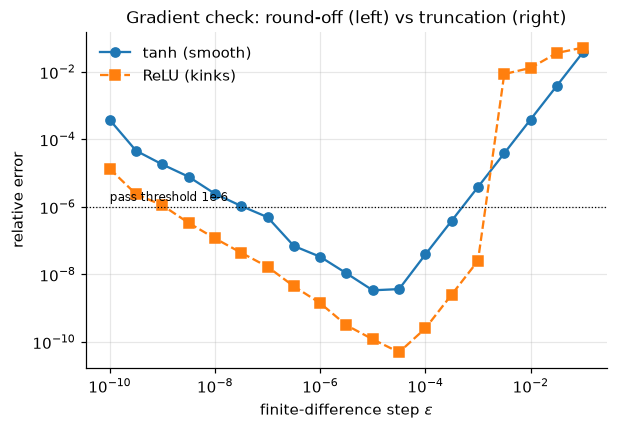

In [6]:
t0 = time.time()
res = gradcheck_part(rng)
show_new_figures(t0, LESSON)


2. Training an MLP on the three-arm spiral


  test accuracy: majority 0.333 | softmax regression 0.330 | MLP 2-64-64-3 1.000  (2.3s)


  saved docs/lesson02/spiral_mlp.png


  saved docs/lesson02/spiral_training.gif
  XOR with one hidden layer of 4 tanh units: accuracy 0.932


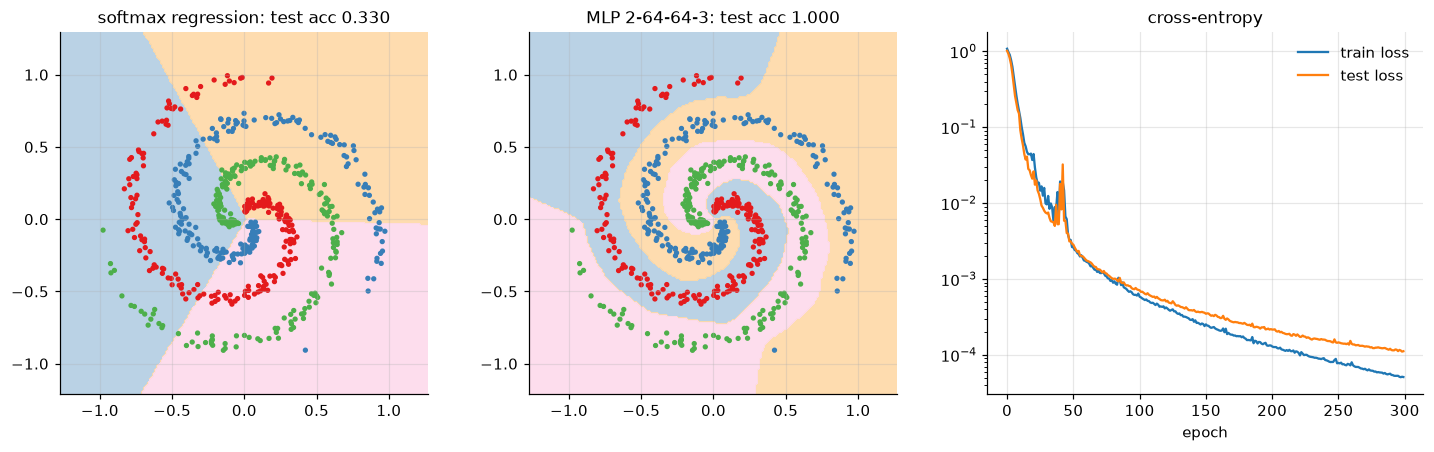

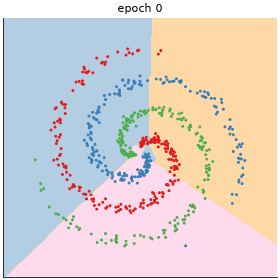

In [7]:
t0 = time.time()
res.update(spiral_part(rng, quick))
show_new_figures(t0, LESSON)

In [8]:
_ = save_results(LESSON, res)

In [9]:
res  # all numbers of this run

{'gradcheck': {'tanh': {'params': 3.3524164549952766e-08,
   'inputs': 1.2915429560500195e-09},
  'relu': {'params': 1.3833927161998533e-09, 'inputs': 5.748468335387447e-10},
  'sigmoid': {'params': 1.8698517158943938e-08,
   'inputs': 2.154763904684439e-08},
  'tanh + batchnorm + dropout': {'params': 2.918651822860192e-09,
   'inputs': 8.555936893422485e-10}},
 'gradcheck_eps': {'eps': [1e-10,
   3.1622776601683795e-10,
   1e-09,
   3.1622776601683795e-09,
   1e-08,
   3.162277660168379e-08,
   1e-07,
   3.162277660168379e-07,
   1e-06,
   3.162277660168379e-06,
   9.999999999999999e-06,
   3.1622776601683795e-05,
   0.0001,
   0.00031622776601683794,
   0.001,
   0.0031622776601683794,
   0.01,
   0.03162277660168379,
   0.1],
  'tanh': [0.00038052919943597636,
   4.640161013379858e-05,
   1.8221175409185248e-05,
   7.860085356435938e-06,
   2.4628290227247544e-06,
   1.0673198608377365e-06,
   4.97991410208994e-07,
   6.999244774721693e-08,
   3.3524164549952766e-08,
   1.0836853662